In [1]:
# ==========================================
# 1. LIBRARIES
# ==========================================
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8')

In [2]:
# ==========================================
# 2. MODEL PARAMETERS
# ==========================================
ticker = "AAPL"       # Stock or index of interest for analysis.
start_date = "2015-01-01"
end_date = "2025-01-01"
confidence_level = 0.95
simulations = 10000  # Monte Carlo

In [3]:
# ==========================================
# 3. DATA DOWNLOAD
# ==========================================
data = yf.download(ticker, start=start_date, end=end_date)
if data.empty:
    raise ValueError("No data downloaded. Check ticker or dates.")

# Use closing prices
prices = data['Close'].dropna()

/tmp/ipykernel_7704/1947245092.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [4]:
# ==========================================
# 4. RETURN CALCULATION
# ==========================================
# Log returns (continuous compounding assumption)
returns = np.log(prices / prices.shift(1)).dropna().squeeze()
# Descriptive statistics
desc_stats = returns.describe()
print("\nDescriptive Statistics:\n", desc_stats)


Descriptive Statistics:
 count    2515.000000
mean        0.000927
std         0.017931
min        -0.137708
25%        -0.007353
50%         0.001000
75%         0.010091
max         0.113158
Name: AAPL, dtype: float64


In [5]:
# ==========================================
# 5. HISTORICAL VaR
# ==========================================
var_hist = np.percentile(returns, (1 - confidence_level) * 100)

# ==========================================
# 6. PARAMETRIC VaR (NORMAL)
# ==========================================
mu = returns.mean()
sigma = returns.std()

z = norm.ppf(1 - confidence_level)
var_param = mu + z * sigma

# ==========================================
# 7. MONTE CARLO VaR
# ==========================================
simulated_returns = np.random.normal(mu, sigma, simulations)
var_mc = np.percentile(simulated_returns, (1 - confidence_level) * 100)


In [6]:
# ==========================================
# 8. RESULTS
# ==========================================
print("=====================================")
print(f"Asset: {ticker}")
print(f"Confidence level: {confidence_level*100}%")
print("=====================================")
print(f"Historical VaR: {var_hist:.4f}")
print(f"Parametric VaR: {var_param:.4f}")
print(f"Monte Carlo VaR: {var_mc:.4f}")
print(f"VaR expressed in return terms (not monetary value)")

Asset: AAPL
Confidence level: 95.0%
Historical VaR: -0.0274
Parametric VaR: -0.0286
Monte Carlo VaR: -0.0286
VaR expressed in return terms (not monetary value)


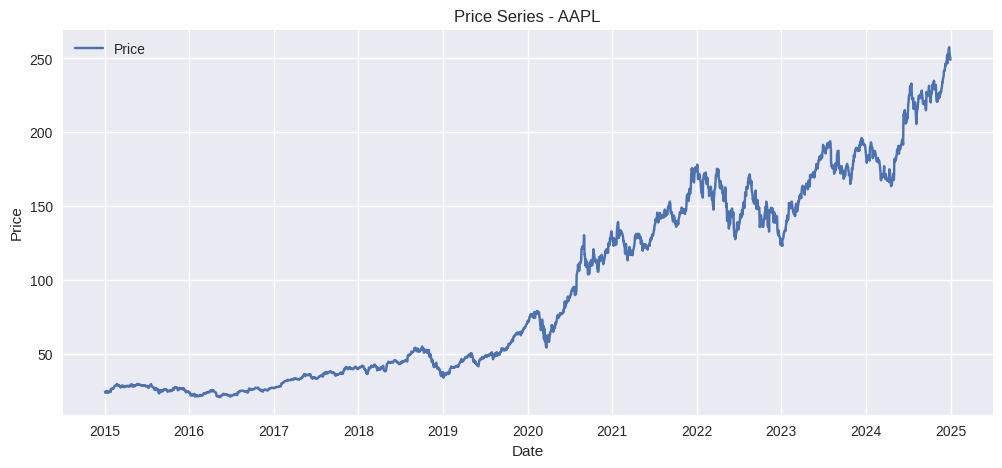

In [7]:
# ==========================================
# 9. PRICE SERIES
# ==========================================
plt.figure(figsize=(12,5))
plt.plot(prices, label="Price")
plt.title(f"Price Series - {ticker}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

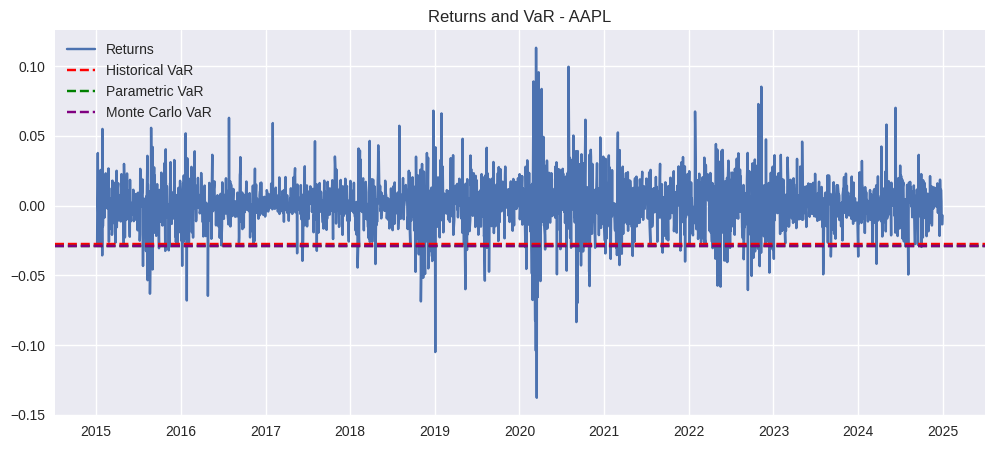

In [8]:
# ==========================================
# 8. RETURNS PLOT
# ==========================================
plt.figure(figsize=(12,5))
plt.plot(returns, label="Returns")
plt.axhline(var_hist, color='red', linestyle='--', label="Historical VaR")
plt.axhline(var_param, color='green', linestyle='--', label="Parametric VaR")
plt.axhline(var_mc, color='purple', linestyle='--', label="Monte Carlo VaR")
plt.title(f"Returns and VaR - {ticker}")
plt.legend()
plt.show()

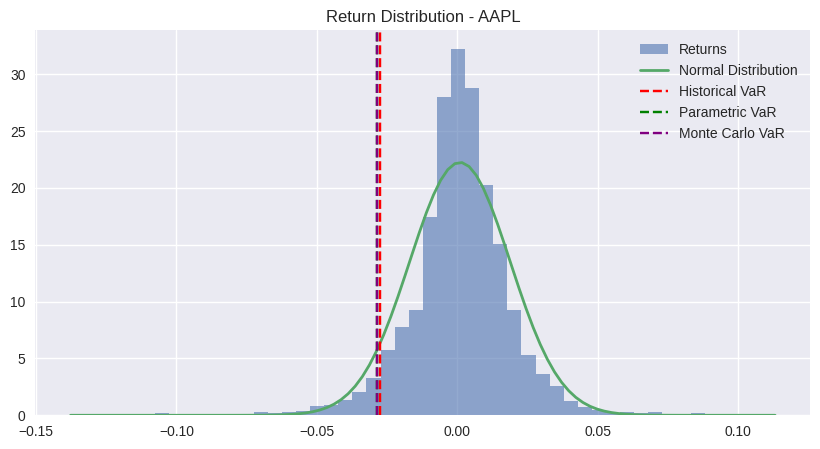

In [9]:
# ==========================================
# 9. HISTOGRAM + VaR
# ==========================================
plt.figure(figsize=(10,5))
plt.hist(returns, bins=50, density=True, alpha=0.6, label="Returns")

# Theoretical normal distribution
x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), label="Normal Distribution", linewidth=2)

# VaR lines
plt.axvline(var_hist, color='red', linestyle='--', label="Historical VaR")
plt.axvline(var_param, color='green', linestyle='--', label="Parametric VaR")
plt.axvline(var_mc, color='purple', linestyle='--', label="Monte Carlo VaR")

plt.title(f"Return Distribution - {ticker}")
plt.legend()
plt.show()